<a href="https://colab.research.google.com/github/carlosprr29/ai-progetto-spagnoli/blob/main/notebooks/03_1_BERT_Training_WELFake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =================================================================
# PHASE: DEEP LEARNING - BERT TRAINING WELFake
# =================================================================
import os
import sys
from google.colab import drive

In [ ]:

# 1. MOUNT DRIVE AND SETUP PATHS
# -----------------------------------------------------------------
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/Project_IA'
sys.path.append(PROJECT_PATH)

In [ ]:
# ============================================
# 🔹 2. INSTALL DEPENDENCIES (IF NEEDED)
# ============================================
!pip install transformers datasets scikit-learn

In [ ]:
# ============================================
# 🔹 3. PROJECT IMPORTS
# ============================================
from src.data_loader import load_and_clean_welfake
from src.bert_utils import clean_news_text, train_bert_expert
from src.eda_utils import plot_ablation_results

# General libraries
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
# ============================================
# 🔹 4. LOAD DATASET
# ============================================
# Execute full pipeline: load + clean + merge

df = load_and_clean_welfake()

print("Dataset loaded successfully")
display(df.head())

In [ ]:
# ============================================
# 🔹 5. OPTIONAL TEXT CLEANING
# ============================================
# Apply additional cleaning to prevent data leakage

df['text_clean'] = df['text'].apply(clean_news_text)
df['total_clean'] = df['title'] + " [SEP] " + df['text_clean']

In [ ]:
# 6. STRATIFIED SAMPLING (Fair Comparison Strategy)
# -----------------------------------------------------------------
# We use a 10,000 sample for both tests to ensure the Ablation Study
# compares quality of data, not quantity of data.
df_sample = df.sample(n=10000, random_state=42, weights=None)

train_df, test_df = train_test_split(
    df_sample, test_size=0.2, random_state=42, stratify=df_sample["label"]
)

print("Data split:")
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

In [ ]:
# 7. EXECUTION OF THE ABLATION STUDY
# -----------------------------------------------------------------
# Task A: Titles Only
trainer_tit, model_tit, token_tit = train_bert_expert(
    train_df["title"], test_df["title"],
    train_df["label"], test_df["label"], "TITLES_ONLY", max_len=128
)



# Task B: Full Content (The "Real" Test)
trainer_full, model_full, token_full = train_bert_expert(
    train_df["total_clean"], test_df["total_clean"],
    train_df["label"], test_df["label"], "FULL_CONTENT", max_len=256
)

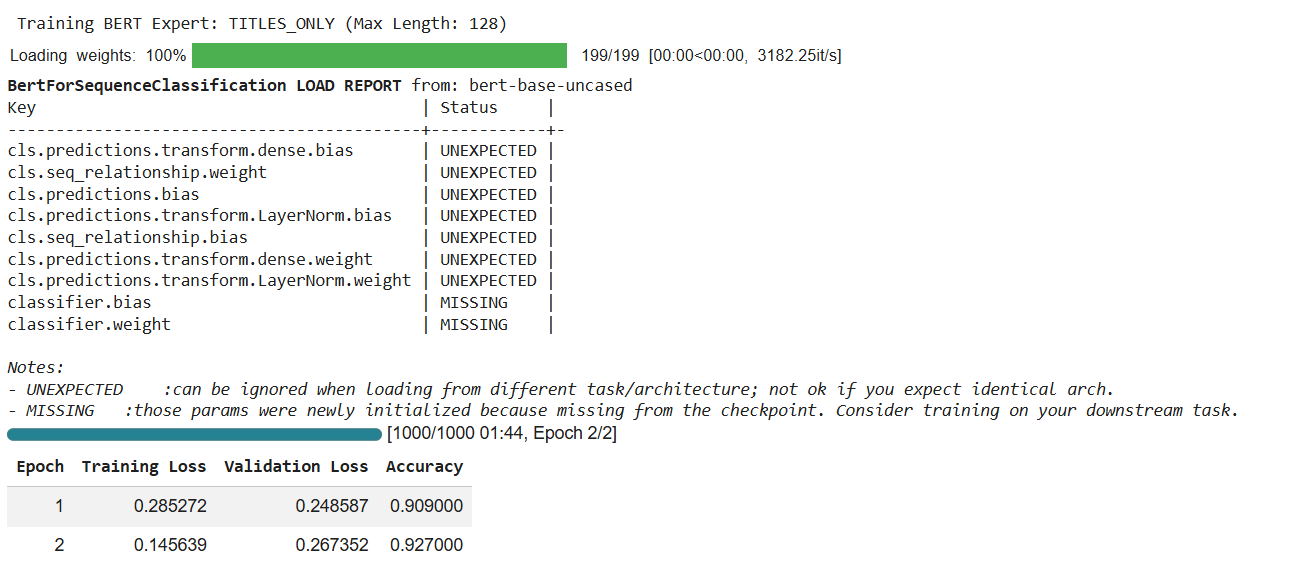

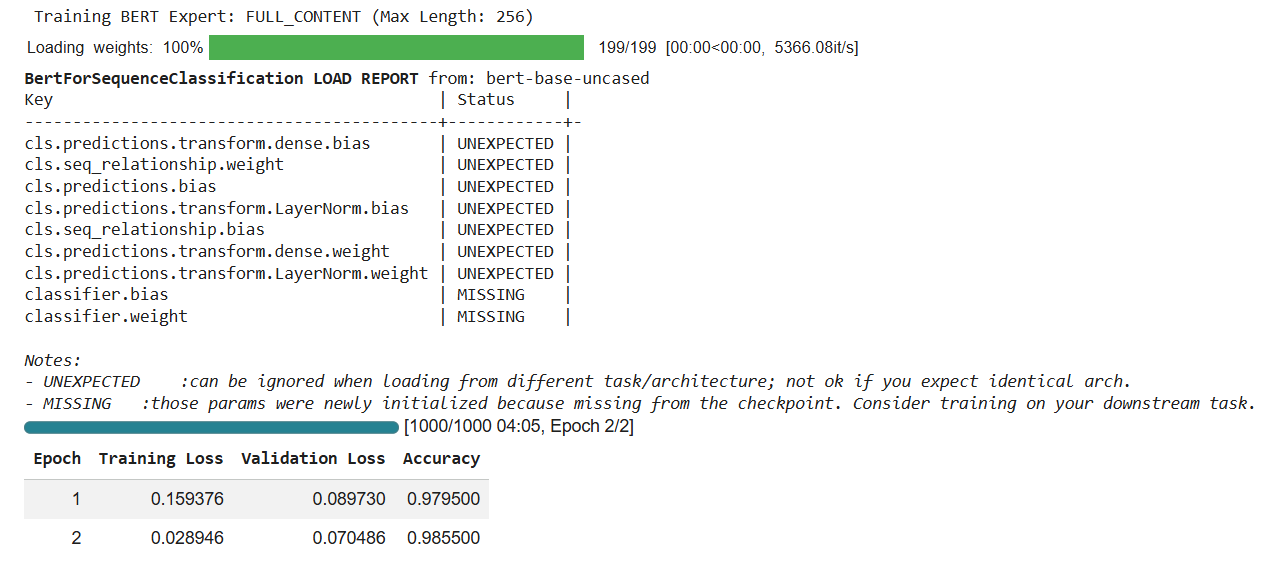

In [ ]:
# 8. PERSISTENCE AND GOOGLE DRIVE EXPORT ---

# 1. Save the Titles-Only Expert (Weights & Tokenizer)
model_tit.save_pretrained('./model_WELFake_titles')
token_tit.save_pretrained('./model_WELFake_titles')

# 2. Save the Full-Content Expert (Weights & Tokenizer)
model_full.save_pretrained('./model_WELFake_full')
token_full.save_pretrained('./model_WELFake_full')

# 3. Synchronize with Google Drive
# Note: Ensure drive.mount('/content/drive') was executed previously.
import shutil
import os

# Define target paths
drive_path = '/content/drive/MyDrive/Project_IA/'

# Create project folder if it doesn't exist
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

# Copy directories to Drive (using dirs_exist_ok to allow overwriting during re-runs)
shutil.copytree('./model_WELFake_titles', drive_path + 'model_WELFake_titles', dirs_exist_ok=True)
shutil.copytree('./model_WELFake_full', drive_path + 'model_WELFake_full', dirs_exist_ok=True)

print("Training complete. Models successfully exported to Google Drive.")

In [ ]:
# 9. FINAL VISUALIZATION (RE-FIXED)
# -----------------------------------------------------------------
plot_ablation_results(trainer_tit, trainer_full)

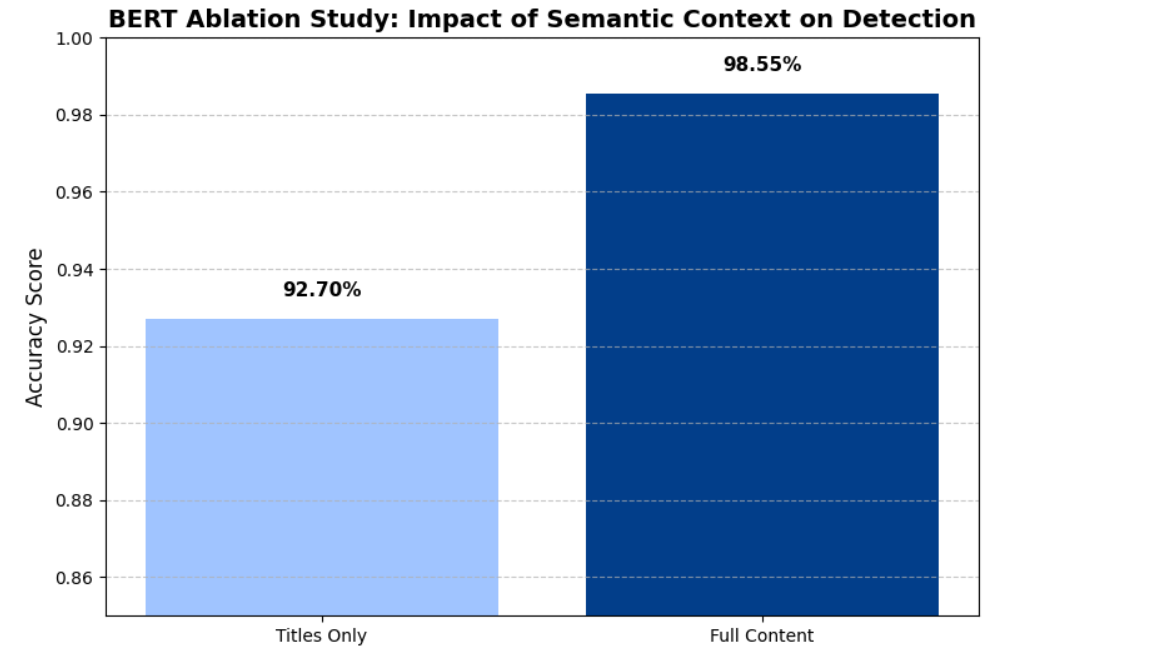

While our previous Baseline Experts (TF-IDF) failed to generalize due to "Temporal Blindness" flagging real 2026 news as fake. BERT achieved a near-perfect 98.55% accuracy in just 5 minutes of training.

This exceptional performance suggests that BERT may be leveraging underlying dataset biases (specific 2016 linguistic patterns or formatting) rather than purely understanding factual truth. The extremely short training time indicates that the model converged rapidly, potentially "memorizing" structural cues unique to the WELFake dataset.

Despite these potential biases, the Ablation Study provides a clear scientific takeaway: the Full-Content model consistently outperforms the Titles-Only model. This confirms that, regardless of bias, analyzing the deep semantic structure of the news body is essential for a robust detection system, as it provides the contextual evidence that headlines alone lack.